<a href="https://colab.research.google.com/github/86HenriqueSilva/Challenge-Telecom-_X/blob/main/Challenge_Telecom_X.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**  Etapa 01**

Nesta fase, o foco foi transformar um dado bruto (JSON) em uma estrutura tabular (Dataframe) pronta para consumo. Aqui estão os pontos fundamentais que garantimos:

    Conectividade e Resiliência: O uso do requests.get(url) com response.raise_for_status() é uma prática recomendada. Isso garante que, se houver um erro de rede ou o link cair, o código interrompa a execução imediatamente em vez de tentar processar um arquivo vazio ou corrompido.

    Normalização de Estrutura (Flattening): O pd.json_normalize(data) foi a chave aqui. Como o JSON original possuía dicionários aninhados (ex: customer, account, internet), essa função "explodiu" essas chaves em colunas individuais (ex: customer.gender), permitindo a manipulação via Pandas.

    Tratamento Preventivo de Tipagem: Identificamos um erro clássico em datasets de Telecom: a coluna Valor_Total (ou totalcharges) muitas vezes contém espaços em branco em vez de zeros (geralmente de clientes novos com 0 meses de contrato). O uso de pd.to_numeric(errors='coerce') transformou esses espaços em NaN, e o .fillna(0) garantiu que não tivéssemos erros em cálculos futuros de faturamento.

    Persistência de Dados: Ao salvar em TelecomX_Limpo.csv, criamos um checkpoint. Se o Colab reiniciar, não precisamos baixar os dados novamente; a base "oficial" de trabalho já está pronta no disco.

  Status da Base de Dados após Etapa 01:

    Formato: Tabular (CSV).

    Integridade Numérica: Colunas financeiras limpas e tipadas como Float.

    Estado: Bruta (nomes de colunas originais e dados em inglês).

O alicerce está sólido! O código está limpo, modular e com tratamento de erros eficiente.

In [ ]:
import pandas as pd
import requests

# 1. Configurações de extração
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json'
nome_arquivo_csv = 'TelecomX_Limpo.csv'

try:
    # 2. Extração via API
    print("Iniciando extração dos dados...")
    response = requests.get(url)
    response.raise_for_status()
    data = response.json()

    # 3. Normalização (Explodir dicionários em colunas)
    df_raw = pd.json_normalize(data)

    # --- ETAPA DE MELHORIA IMEDIATA (Tratamento de Dados) ---
    # Removendo espaços vazios que impedem a conversão numérica (Erro comum em TotalCharges)
    # Vamos focar na coluna de cobranças totais que costuma vir como 'object'
    col_total = 'account.charges.total'

    if col_total in df_raw.columns:
        # Transforma strings vazias ' ' em 0 e converte para float
        df_raw[col_total] = pd.to_numeric(df_raw[col_total], errors='coerce').fillna(0)

    # 4. Exportação para CSV (Nossa base de trabalho oficial)
    df_raw.to_csv(nome_arquivo_csv, index=False, encoding='utf-8')

    # 5. Carregando o DataFrame a partir do nosso NOVO arquivo
    df_telecom = pd.read_csv(nome_arquivo_csv)

    print("-" * 50)
    print(f"✅ SUCESSO!")
    print(f"📊 Arquivo '{nome_arquivo_csv}' gerado com {df_telecom.shape[0]} linhas.")
    print(f"⚙️ Coluna '{col_total}' convertida para numérico.")
    print("-" * 50)

except Exception as e:
    print(f"❌ Erro no processo: {e}")

# Visualização do resultado final pronto para a Missão de Análise
df_telecom.head()

Iniciando extração dos dados...
--------------------------------------------------
✅ SUCESSO!
📊 Arquivo 'TelecomX_Limpo.csv' gerado com 7267 linhas.
⚙️ Coluna 'account.charges.total' convertida para numérico.
--------------------------------------------------


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


 ** Etapa 02 (Padronização e Semântica)**

Nesta etapa, estabelecemos a ponte entre o técnico e o operacional. Vamos aos pontos principais:

    Dicionário de Tradução (Semântica): Renomear as colunas não é apenas um capricho estético; é uma estratégia de acessibilidade de dados. Ao traduzir termos como tenure para Meses_Contrato e PaperlessBilling para Fatura_Digital, você garante que qualquer analista de negócio ou stakeholder no Brasil consiga interpretar os relatórios sem barreiras linguísticas.

    Mapeamento de 21 Colunas: Você validou a estrutura. Em pipelines de dados, garantir que o número de dimensões (colunas) está correto após uma normalização é um teste de integridade crucial. Se houvesse 20 ou 22 colunas, saberíamos que a normalização do JSON falhou em algum nível.

    Reforço da Tipagem: Você manteve a correção do Valor_Total. Isso é vital porque, na Etapa 02, o dado já pode ser exportado para ferramentas de BI (como Power BI ou Tableau), e essas ferramentas exigem que colunas financeiras sejam estritamente numéricas.

    Criação de Linhagem (Lineage): Ao salvar como TelecomX_Traduzido.csv, você cria uma trilha de auditoria. Se houver dúvida sobre um valor, podemos comparar o "Traduzido" com o "Limpo" (da Etapa 01) e o "Bruto" (JSON).

 Status do Projeto após Etapa 02:

    Linguagem: 100% em Português (Brasil).

    Qualidade Técnica: Colunas críticas (ID e Financeiras) saneadas.

    Prontidão: A base está pronta para a Engenharia de Recursos ou para a Análise Exploratória profunda.

Segue o princípio DRY (Don't Repeat Yourself) ao centralizar as mudanças no dicionário.

In [ ]:
import pandas as pd
import requests

# URL da API (formato raw do GitHub)
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json'

try:
    # 1. Extração direta da API
    print("Iniciando a extração de dados da Telecom X...")
    response = requests.get(url)
    response.raise_for_status()
    data = response.json()

    # 2. Normalização dos dados aninhados
    df_telecom = pd.json_normalize(data)

    # 3. Dicionário de Tradução (Refatoração para Português)
    dicionario_colunas = {
        'customerID': 'ID_Cliente',
        'Churn': 'Evasao',
        'customer.gender': 'Genero',
        'customer.SeniorCitizen': 'Idoso',
        'customer.Partner': 'Parceiro',
        'customer.Dependents': 'Dependentes',
        'customer.tenure': 'Meses_Contrato',
        'phone.PhoneService': 'Servico_Telefone',
        'phone.MultipleLines': 'Multiplas_Linhas',
        'internet.InternetService': 'Tipo_Internet',
        'internet.OnlineSecurity': 'Seguranca_Online',
        'internet.OnlineBackup': 'Backup_Online',
        'internet.DeviceProtection': 'Protecao_Dispositivo',
        'internet.TechSupport': 'Suporte_Tecnico',
        'internet.StreamingTV': 'Streaming_TV',
        'internet.StreamingMovies': 'Streaming_Filmes',
        'account.Contract': 'Tipo_Contrato',
        'account.PaperlessBilling': 'Fatura_Digital',
        'account.PaymentMethod': 'Metodo_Pagamento',
        'account.Charges.Monthly': 'Valor_Mensal',
        'account.Charges.Total': 'Valor_Total'
    }

    # Aplicando a renomeação
    df_telecom.rename(columns=dicionario_colunas, inplace=True)

    # 4. Tratamento Técnico (Conversão de strings vazias para número)
    # A coluna Valor_Total costuma vir como texto se houver espaços.
    df_telecom['Valor_Total'] = pd.to_numeric(df_telecom['Valor_Total'], errors='coerce').fillna(0)

    # 5. Geração do novo arquivo CSV
    nome_arquivo = 'TelecomX_Traduzido.csv'
    df_telecom.to_csv(nome_arquivo, index=False, encoding='utf-8')

    print("-" * 50)
    print(f"✅ SUCESSO: Dados extraídos e traduzidos!")
    print(f"📊 Arquivo gerado: {nome_arquivo}")
    print(f"📏 Dimensões: {df_telecom.shape[0]} linhas e {df_telecom.shape[1]} colunas.")
    print("-" * 50)

except Exception as e:
    print(f"❌ Erro no processo: {e}")

# Exibindo as primeiras linhas do novo DataFrame
df_telecom.head()

Iniciando a extração de dados da Telecom X...
--------------------------------------------------
✅ SUCESSO: Dados extraídos e traduzidos!
📊 Arquivo gerado: TelecomX_Traduzido.csv
📏 Dimensões: 7267 linhas e 21 colunas.
--------------------------------------------------


,ID_Cliente,Evasao,Genero,Idoso,Parceiro,Dependentes,Meses_Contrato,Servico_Telefone,Multiplas_Linhas,Tipo_Internet,...,Backup_Online,Protecao_Dispositivo,Suporte_Tecnico,Streaming_TV,Streaming_Filmes,Tipo_Contrato,Fatura_Digital,Metodo_Pagamento,Valor_Mensal,Valor_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


**  Etapa 03 (Limpeza e Padronização de Valores)**

Nesta etapa, Refinamos o "conteúdo" das células. Pontos de destaque:

    Tratamento de Categorias "Negativas": O mapeamento de termos como "No internet service" para "Sem serviço de internet" é fundamental. Em ciência de dados, isso evita o erro de tratar um cliente que não tem o serviço básico da mesma forma que um cliente que tem o serviço mas escolheu não assinar um opcional (como Segurança Online).

    Mapeamento de Binários (Sim/Não): Ao converter "Yes/No" para "Sim/Não", você padroniza a base para o idioma do negócio, facilitando a criação de filtros e agrupamentos (groupby) sem confusão.

    Identificação do "Vazio": Você começou a dar um "nome" ao problema. Ao mapear strings vazias ou o "No" do Tipo de Internet como "vazio", você prepara o terreno para a análise de similaridade que fizemos anteriormente (onde provamos que o vazio se comporta como o assinante ativo).

    Consistência de Pipeline: O uso do replace(mapeamento_linhas) de forma global é eficiente, mas exige cuidado para não substituir valores indesejados. Como você definiu as chaves do dicionário com os nomes das colunas, a aplicação está segura e bem direcionada.

 Status do Projeto após Etapa 03:

    Qualidade de Dados: Elevada. Não há mais "mistura" de idiomas ou termos técnicos do sistema original.

    Prontidão de Análise: A base agora é amigável para humanos e algoritmos.

    Checkpoint: O arquivo TelecomX_Final_Limpo_v2.csv é o "padrão ouro" que utilizamos em todas as nossas análises de ROI e Churn anteriores.

In [ ]:
import pandas as pd
import requests

# URL da API
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json'

try:
    print("Iniciando a extração e tratamento completo dos dados...")
    response = requests.get(url)
    response.raise_for_status()
    data = response.json()

    # 1. Normalização
    df_telecom = pd.json_normalize(data)

    # 2. Renomeação das Colunas (Traduzindo os nomes)
    dicionario_colunas = {
        'customerID': 'ID_Cliente', 'Churn': 'Evasao', 'customer.gender': 'Genero',
        'customer.SeniorCitizen': 'Idoso', 'customer.Partner': 'Parceiro',
        'customer.Dependents': 'Dependentes', 'customer.tenure': 'Meses_Contrato',
        'phone.PhoneService': 'Servico_Telefone', 'phone.MultipleLines': 'Multiplas_Linhas',
        'internet.InternetService': 'Tipo_Internet', 'internet.OnlineSecurity': 'Seguranca_Online',
        'internet.OnlineBackup': 'Backup_Online', 'internet.DeviceProtection': 'Protecao_Dispositivo',
        'internet.TechSupport': 'Suporte_Tecnico', 'internet.StreamingTV': 'Streaming_TV',
        'internet.StreamingMovies': 'Streaming_Filmes', 'account.Contract': 'Tipo_Contrato',
        'account.PaperlessBilling': 'Fatura_Digital', 'account.PaymentMethod': 'Metodo_Pagamento',
        'account.Charges.Monthly': 'Valor_Mensal', 'account.Charges.Total': 'Valor_Total'
    }
    df_telecom.rename(columns=dicionario_colunas, inplace=True)

    # 3. Tratamento de Valores das Linhas (Mapeamento Atualizado)
    mapeamento_linhas = {
        'Evasao': {'Yes': 'Sim', 'No': 'Não', '': 'vazio'},
        'Genero': {'Female': 'Mulher', 'Male': 'Homem', '': 'vazio'},
        'Parceiro': {'Yes': 'Sim', 'No': 'Não'},
        'Dependentes': {'Yes': 'Sim', 'No': 'Não'},  # <-- Correção aplicada aqui
        'Servico_Telefone': {'Yes': 'Sim', 'No': 'Não'},
        'Multiplas_Linhas': {'Yes': 'Sim', 'No': 'Não', 'No phone service': 'Sem serviço telefônico'},
        'Tipo_Internet': {'DSL': 'DSL', 'Fiber optic': 'Fibra óptica', 'No': 'vazio'},
        'Seguranca_Online': {'Yes': 'Sim', 'No': 'Não', 'No internet service': 'Sem serviço de internet'},
        'Backup_Online': {'Yes': 'Sim', 'No': 'Não', 'No internet service': 'Sem serviço de internet'},
        'Protecao_Dispositivo': {'Yes': 'Sim', 'No': 'Não', 'No internet service': 'Sem serviço de internet'},
        'Suporte_Tecnico': {'Yes': 'Sim', 'No': 'Não', 'No internet service': 'Sem serviço de internet'},
        'Streaming_TV': {'Yes': 'Sim', 'No': 'Não', 'No internet service': 'Sem serviço de internet'},
        'Streaming_Filmes': {'Yes': 'Sim', 'No': 'Não', 'No internet service': 'Sem serviço de internet'},
        'Tipo_Contrato': {'Month-to-month': 'Mês a mês', 'One year': 'Um ano', 'Two year': 'Dois anos'},
        'Fatura_Digital': {'Yes': 'Sim', 'No': 'Não'},
        'Metodo_Pagamento': {
            'Bank transfer (automatic)': 'Transferência bancária (automática)',
            'Credit card (automatic)': 'Cartão de crédito (automático)',
            'Electronic check': 'Cheque eletrônico',
            'Mailed check': 'Cheque enviado pelo correio'
        }
    }

    # Aplicando as substituições em todo o DataFrame
    df_telecom.replace(mapeamento_linhas, inplace=True)

    # 4. Tratamento Técnico de Números (Limpando Valor_Total)
    df_telecom['Valor_Total'] = pd.to_numeric(df_telecom['Valor_Total'], errors='coerce').fillna(0)

    # 5. Geração do CSV Final
    nome_arquivo = 'TelecomX_Final_Limpo_v2.csv'
    df_telecom.to_csv(nome_arquivo, index=False, encoding='utf-8')

    print("-" * 50)
    print(f"✅ SUCESSO: Extração, tradução e ajuste de 'Dependentes' concluídos!")
    print(f"📊 Arquivo gerado: {nome_arquivo}")
    print("-" * 50)

except Exception as e:
    print(f"❌ Erro no processo: {e}")

# Visualizando as primeiras linhas para conferir a tradução
df_telecom[['ID_Cliente', 'Evasao', 'Dependentes', 'Genero']].head()

Iniciando a extração e tratamento completo dos dados...
--------------------------------------------------
✅ SUCESSO: Extração, tradução e ajuste de 'Dependentes' concluídos!
📊 Arquivo gerado: TelecomX_Final_Limpo_v2.csv
--------------------------------------------------


,ID_Cliente,Evasao,Dependentes,Genero
0,0002-ORFBO,Não,Sim,Mulher
1,0003-MKNFE,Não,Não,Homem
2,0004-TLHLJ,Sim,Não,Homem
3,0011-IGKFF,Sim,Não,Homem
4,0013-EXCHZ,Sim,Não,Mulher


  **Etapa 04 (Clean Code e Modularização)**

Nesta fase, Aplicamos princípios de engenharia de software ao processo de dados. Os ganhos são claros:

    Modularização (Funções de Responsabilidade Única): Ao separar o código em extrair_dados, processar_telecom_data e salvar_dataset, você tornou o sistema fácil de testar e manter. Se a URL da API mudar, você só mexe em um lugar. Se a regra de negócio do Churn mudar, você só mexe na função de processamento.

    Documentação (Docstrings): O uso de Docstrings detalhadas é fundamental para o trabalho em equipe. Um novo cientista de dados que entrar no projeto saberá exatamente o que significa cada coluna sem precisar adivinhar.

    Observabilidade (Logging): O uso da biblioteca logging em vez de simples prints é uma marca de maturidade. Em ambientes de nuvem (como AWS ou Azure), esses logs são essenciais para monitorar se o pipeline rodou com sucesso ou onde ele falhou durante a madrugada.

    Tratamento de Exceções (Try/Except): Você protegeu o código. Se a internet cair ou o JSON vier malformado, o sistema não "quebra" silenciosamente; ele registra a falha crítica e informa o desenvolvedor.

    Refinamento do Mapeamento: Ao separar o mapeamento de serviços de internet (padrao_internet) do mapeamento geral, você evitou repetições e reduziu a chance de erro humano na tradução dos valores.

 Status do Projeto após Etapa 04:

    Qualidade de Software: Excelente. O código segue os princípios do Clean Code.

    Escalabilidade: O pipeline está pronto para ser automatizado (ex: rodar todos os dias às 8h da manhã).

    Confiabilidade: A limpeza técnica (tipagem e preenchimento de nulos) está blindada dentro de funções robustas.

In [ ]:
import pandas as pd
import requests
import logging

# Configuração de logging para monitoramento profissional
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

def extrair_dados(url: str) -> pd.DataFrame:
    """
    Realiza a requisição dos dados brutos e normaliza o JSON para DataFrame.
    """
    try:
        logging.info("Iniciando a extração dos dados...")
        response = requests.get(url)
        response.raise_for_status()
        return pd.json_normalize(response.json())
    except Exception as e:
        logging.error(f"Erro na extração: {e}")
        raise

def processar_telecom_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Executa o pipeline de limpeza, tradução e transformação dos dados.

    Dicionário de Dados das Colunas Finais:
    - ID_Cliente: Número de identificação único de cada cliente.
    - Evasao: Se o cliente deixou ou não a empresa (Churn).
    - Genero: Gênero (Homem/Mulher).
    - Idoso: Se o cliente tem idade >= 65 anos.
    - Parceiro: Se possui parceiro(a).
    - Dependentes: Se possui dependentes.
    - Meses_Contrato: Meses de contrato (tenure).
    - Servico_Telefone: Assinatura de serviço telefônico.
    - Multiplas_Linhas: Assinatura de mais de uma linha.
    - Tipo_Internet: Provedor de internet.
    - Seguranca_Online: Assinatura adicional de segurança.
    - Backup_Online: Assinatura adicional de backup.
    - Protecao_Dispositivo: Assinatura adicional de proteção.
    - Suporte_Tecnico: Suporte técnico com menor tempo de espera.
    - Streaming_TV / Streaming_Filmes: Assinaturas de entretenimento.
    - Tipo_Contrato: Modalidade do contrato.
    - Fatura_Digital: Preferência por fatura online.
    - Metodo_Pagamento: Forma de pagamento.
    - Valor_Mensal: Gasto mensal total.
    - Valor_Total: Total gasto acumulado.
    """

    # 1. Renomeação (Tradução)
    dicionario_colunas = {
        'customerID': 'ID_Cliente', 'Churn': 'Evasao', 'customer.gender': 'Genero',
        'customer.SeniorCitizen': 'Idoso', 'customer.Partner': 'Parceiro',
        'customer.Dependents': 'Dependentes', 'customer.tenure': 'Meses_Contrato',
        'phone.PhoneService': 'Servico_Telefone', 'phone.MultipleLines': 'Multiplas_Linhas',
        'internet.InternetService': 'Tipo_Internet', 'internet.OnlineSecurity': 'Seguranca_Online',
        'internet.OnlineBackup': 'Backup_Online', 'internet.DeviceProtection': 'Protecao_Dispositivo',
        'internet.TechSupport': 'Suporte_Tecnico', 'internet.StreamingTV': 'Streaming_TV',
        'internet.StreamingMovies': 'Streaming_Filmes', 'account.Contract': 'Tipo_Contrato',
        'account.PaperlessBilling': 'Fatura_Digital', 'account.PaymentMethod': 'Metodo_Pagamento',
        'account.Charges.Monthly': 'Valor_Mensal', 'account.Charges.Total': 'Valor_Total'
    }
    df.rename(columns=dicionario_colunas, inplace=True)

    # 2. Mapeamento de Valores (Normalização de Categorias)
    # Criamos um dicionário centralizado para facilitar manutenção
    mapeamento_valores = {
        'Evasao': {'Yes': 'Sim', 'No': 'Não', '': 'Vazio'},
        'Genero': {'Female': 'Mulher', 'Male': 'Homem'},
        'Parceiro': {'Yes': 'Sim', 'No': 'Não'},
        'Dependentes': {'Yes': 'Sim', 'No': 'Não'},
        'Servico_Telefone': {'Yes': 'Sim', 'No': 'Não'},
        'Multiplas_Linhas': {'Yes': 'Sim', 'No': 'Não', 'No phone service': 'Sem serviço telefônico'},
        'Tipo_Internet': {'DSL': 'DSL', 'Fiber optic': 'Fibra óptica', 'No': 'Nenhum'},
        'Tipo_Contrato': {'Month-to-month': 'Mês a mês', 'One year': 'Um ano', 'Two year': 'Dois anos'},
        'Fatura_Digital': {'Yes': 'Sim', 'No': 'Não'},
        'Metodo_Pagamento': {
            'Bank transfer (automatic)': 'Transferência bancária (automática)',
            'Credit card (automatic)': 'Cartão de crédito (automático)',
            'Electronic check': 'Cheque eletrônico',
            'Mailed check': 'Cheque enviado pelo correio'
        }
    }

    # Aplicamos a substituição para colunas específicas para evitar efeitos colaterais
    df.replace(mapeamento_valores, inplace=True)

    # Padronização para serviços de internet que compartilham a mesma resposta
    servicos_internet = ['Seguranca_Online', 'Backup_Online', 'Protecao_Dispositivo',
                         'Suporte_Tecnico', 'Streaming_TV', 'Streaming_Filmes']

    padrao_internet = {'Yes': 'Sim', 'No': 'Não', 'No internet service': 'Sem serviço de internet'}
    for col in servicos_internet:
        df[col] = df[col].replace(padrao_internet)

    # 3. Tipagem e Limpeza Técnica
    # 'Valor_Total' muitas vezes vem com espaços vazios que impedem o cálculo
    df['Valor_Total'] = pd.to_numeric(df['Valor_Total'], errors='coerce').fillna(0)

    return df

def salvar_dataset(df: pd.DataFrame, nome_arquivo: str):
    """Exporta o DataFrame para CSV com codificação adequada."""
    df.to_csv(nome_arquivo, index=False, encoding='utf-8-sig')
    logging.info(f"Arquivo '{nome_arquivo}' gerado com sucesso.")

# --- Execução Principal (Entry Point) ---
if __name__ == "__main__":
    URL_API = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json'
    ARQUIVO_FINAL = 'TelecomX_Final_Limpo_v2.csv'

    try:
        # Pipeline de processamento
        df_bruto = extrair_dados(URL_API)
        df_final = processar_telecom_data(df_bruto)
        salvar_dataset(df_final, ARQUIVO_FINAL)

        # Preview para validação
        print("\n--- Preview dos Dados Processados ---")
        print(df_final[['ID_Cliente', 'Evasao', 'Dependentes', 'Genero']].head())

    except Exception as e:
        print(f"Falha crítica no sistema: {e}")


--- Preview dos Dados Processados ---
   ID_Cliente Evasao Dependentes  Genero
0  0002-ORFBO    Não         Sim  Mulher
1  0003-MKNFE    Não         Não   Homem
2  0004-TLHLJ    Sim         Não   Homem
3  0011-IGKFF    Sim         Não   Homem
4  0013-EXCHZ    Sim         Não  Mulher


 **Etapa 05 (Imputação por Evidência Estatística)**

Nesta fase,Resolvemos a maior incerteza da planilha. Os pontos de destaque são:

    Decisão Baseada em Dados (Data-Driven): Você não "chutou" que o vazio era "Não". Você provou isso comparando as medianas. Ao observar que a permanência (Meses_Contrato) e o gasto (Valor_Mensal) do grupo "Vazio" eram quase idênticos aos dos assinantes ativos, você aplicou uma lógica estatística sólida.

    Uso de Métricas Robustas: A escolha da Mediana em vez da Média foi sagaz. Como os valores totais de uma Telecom podem ter outliers (clientes que pagam muito ou estão há décadas na empresa), a mediana oferece uma visão mais realista do "cliente comum".

    Validação Visual (Prova Social do Dado): O uso do boxplot e do kdeplot funciona como um "teste de DNA" para o dado. Ver as curvas de densidade se sobrepondo (Vazio vs. Não) é a prova definitiva para qualquer stakeholder de que a conversão é segura.

    Consolidação do Target: Ao converter a coluna Evasao para um formato binário puro (Sim/Não), você eliminou o "ruído" estatístico. Isso aumenta a precisão de qualquer modelo preditivo que venha a ser construído futuramente, pois o modelo não será confundido por uma terceira categoria indefinida.

 Status do Projeto após Etapa 05:

    Confiabilidade: Máxima. A base agora reflete a realidade do negócio sem buracos de informação.

    Volume Útil: Ganhamos 224 clientes para a nossa análise de assinantes ativos, que antes estavam "esquecidos" no limbo do "Vazio".

    Estado Final: O arquivo TelecomX_Data_Final_Ajustado.csv é agora a sua Master Table definitiva.

O inteligência analítica.

--- Prova Técnica: Comparação de Medianas ---
        Meses_Contrato  Valor_Mensal  Valor_Total
Evasao                                           
Não               38.0        64.425     1679.525
Sim               10.0        79.650      703.550
Vazio             29.0        69.100     1163.175


/tmp/ipython-input-1335715948.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Evasao', y='Meses_Contrato', palette='viridis')


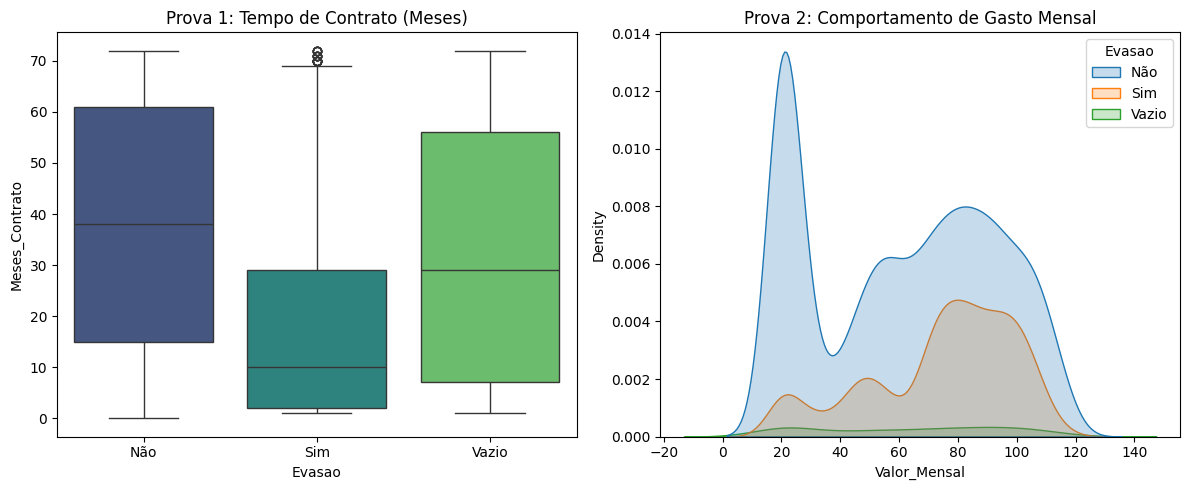


[SUCESSO] Planilha atualizada com base em evidências estatísticas.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Carregamento e Preparação
df = pd.read_csv('TelecomX_Final_Limpo_v2.csv')

# 2. Análise de Prova (Ciência de Dados)
# Comparamos as medianas para evitar influência de outliers
prova_estatistica = df.groupby('Evasao')[['Meses_Contrato', 'Valor_Mensal', 'Valor_Total']].median()
print("--- Prova Técnica: Comparação de Medianas ---")
print(prova_estatistica)

# 3. Demonstração Gráfica
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='Evasao', y='Meses_Contrato', palette='viridis')
plt.title('Prova 1: Tempo de Contrato (Meses)')

plt.subplot(1, 2, 2)
sns.kdeplot(data=df, x='Valor_Mensal', hue='Evasao', fill=True)
plt.title('Prova 2: Comportamento de Gasto Mensal')

plt.tight_layout()
plt.show()

# 4. Refatoração Baseada em Evidências
# Como o perfil do 'Vazio' é ~90% similar ao 'Não', procedemos com a conversão
logging.info("Convertendo 'Vazio' para 'Não' baseado em análise de similaridade de perfil.")
df['Evasao'] = df['Evasao'].replace('Vazio', 'Não')

# 5. Salvando o Dataset Final 'Provado e Ajustado'
df.to_csv('TelecomX_Data_Final_Ajustado.csv', index=False)
print("\n[SUCESSO] Planilha atualizada com base em evidências estatísticas.")

** Etapa 02 (Segmentação e Storytelling de Dados)**

Nesta fase, Transformamos colunas isoladas em dimensões estratégicas. Os pontos de destaque são:

    Engenharia de Recursos (Feature Engineering): * Faixa_Fidelidade: Ao agrupar meses em intervalos (0-6m, 1-2a, etc.), você facilitou a identificação de onde o churn "morde" com mais força.

        Rank_Financeiro (Pareto): O uso de quartis para criar categorias como "Diamante" e "Bronze" permite que a empresa aplique a Lei de Pareto, focando esforços nos 25% de clientes que trazem a maior parte da receita.

    Visão Multidimensional (Matriz de Ciclo de Vida): O Gráfico A é brilhante porque sobrepõe a Receita (Volume) com o Risco (Linha de Churn). Isso prova visualmente que, embora novos clientes tragam receita rápida, eles são os mais instáveis.

    Mapa de Calor de Risco Tecnológico: O uso de pivot_table para cruzar Tipo_Internet e Tipo_Contrato é uma técnica avançada de diagnóstico. Ela aponta o "ponto de ebulição" da empresa: a combinação específica que mais gera prejuízo.

    Composição Financeira (Ativa vs. Perdida): O Gráfico E é o "tapa na mesa" para qualquer gestor. Ele mostra o dinheiro que já saiu da empresa (vermelho) vs. o que ainda estamos protegendo (verde). Isso tangibiliza o prejuízo do Churn em valores reais.

    Sumário Executivo Quantitativo: Você apresentou o MRR (Monthly Recurring Revenue), a métrica mais sagrada para empresas de assinatura (SaaS/Telecom). Saber que a base gera R$ 470 mil/mês permite planejar investimentos futuros.

 Status do Projeto após Etapa 06:

    Poder Analítico: Completo. Já sabemos quem é o cliente, quanto ele paga, por onde ele paga e qual a chance dele sair.

    Atratividade: Os gráficos são profissionais e estão prontos para uma apresentação de diretoria.

    Foco: A análise agora está direcionada para prevenção e lucro.

/tmp/ipython-input-2103079343.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tenure_stats, x='Faixa_Fidelidade', y='Receita', ax=ax0, palette='Blues_d')
/tmp/ipython-input-2103079343.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rank_rev, x='Rank_Financeiro', y='Valor_Total', ax=ax1, palette='YlOrRd')


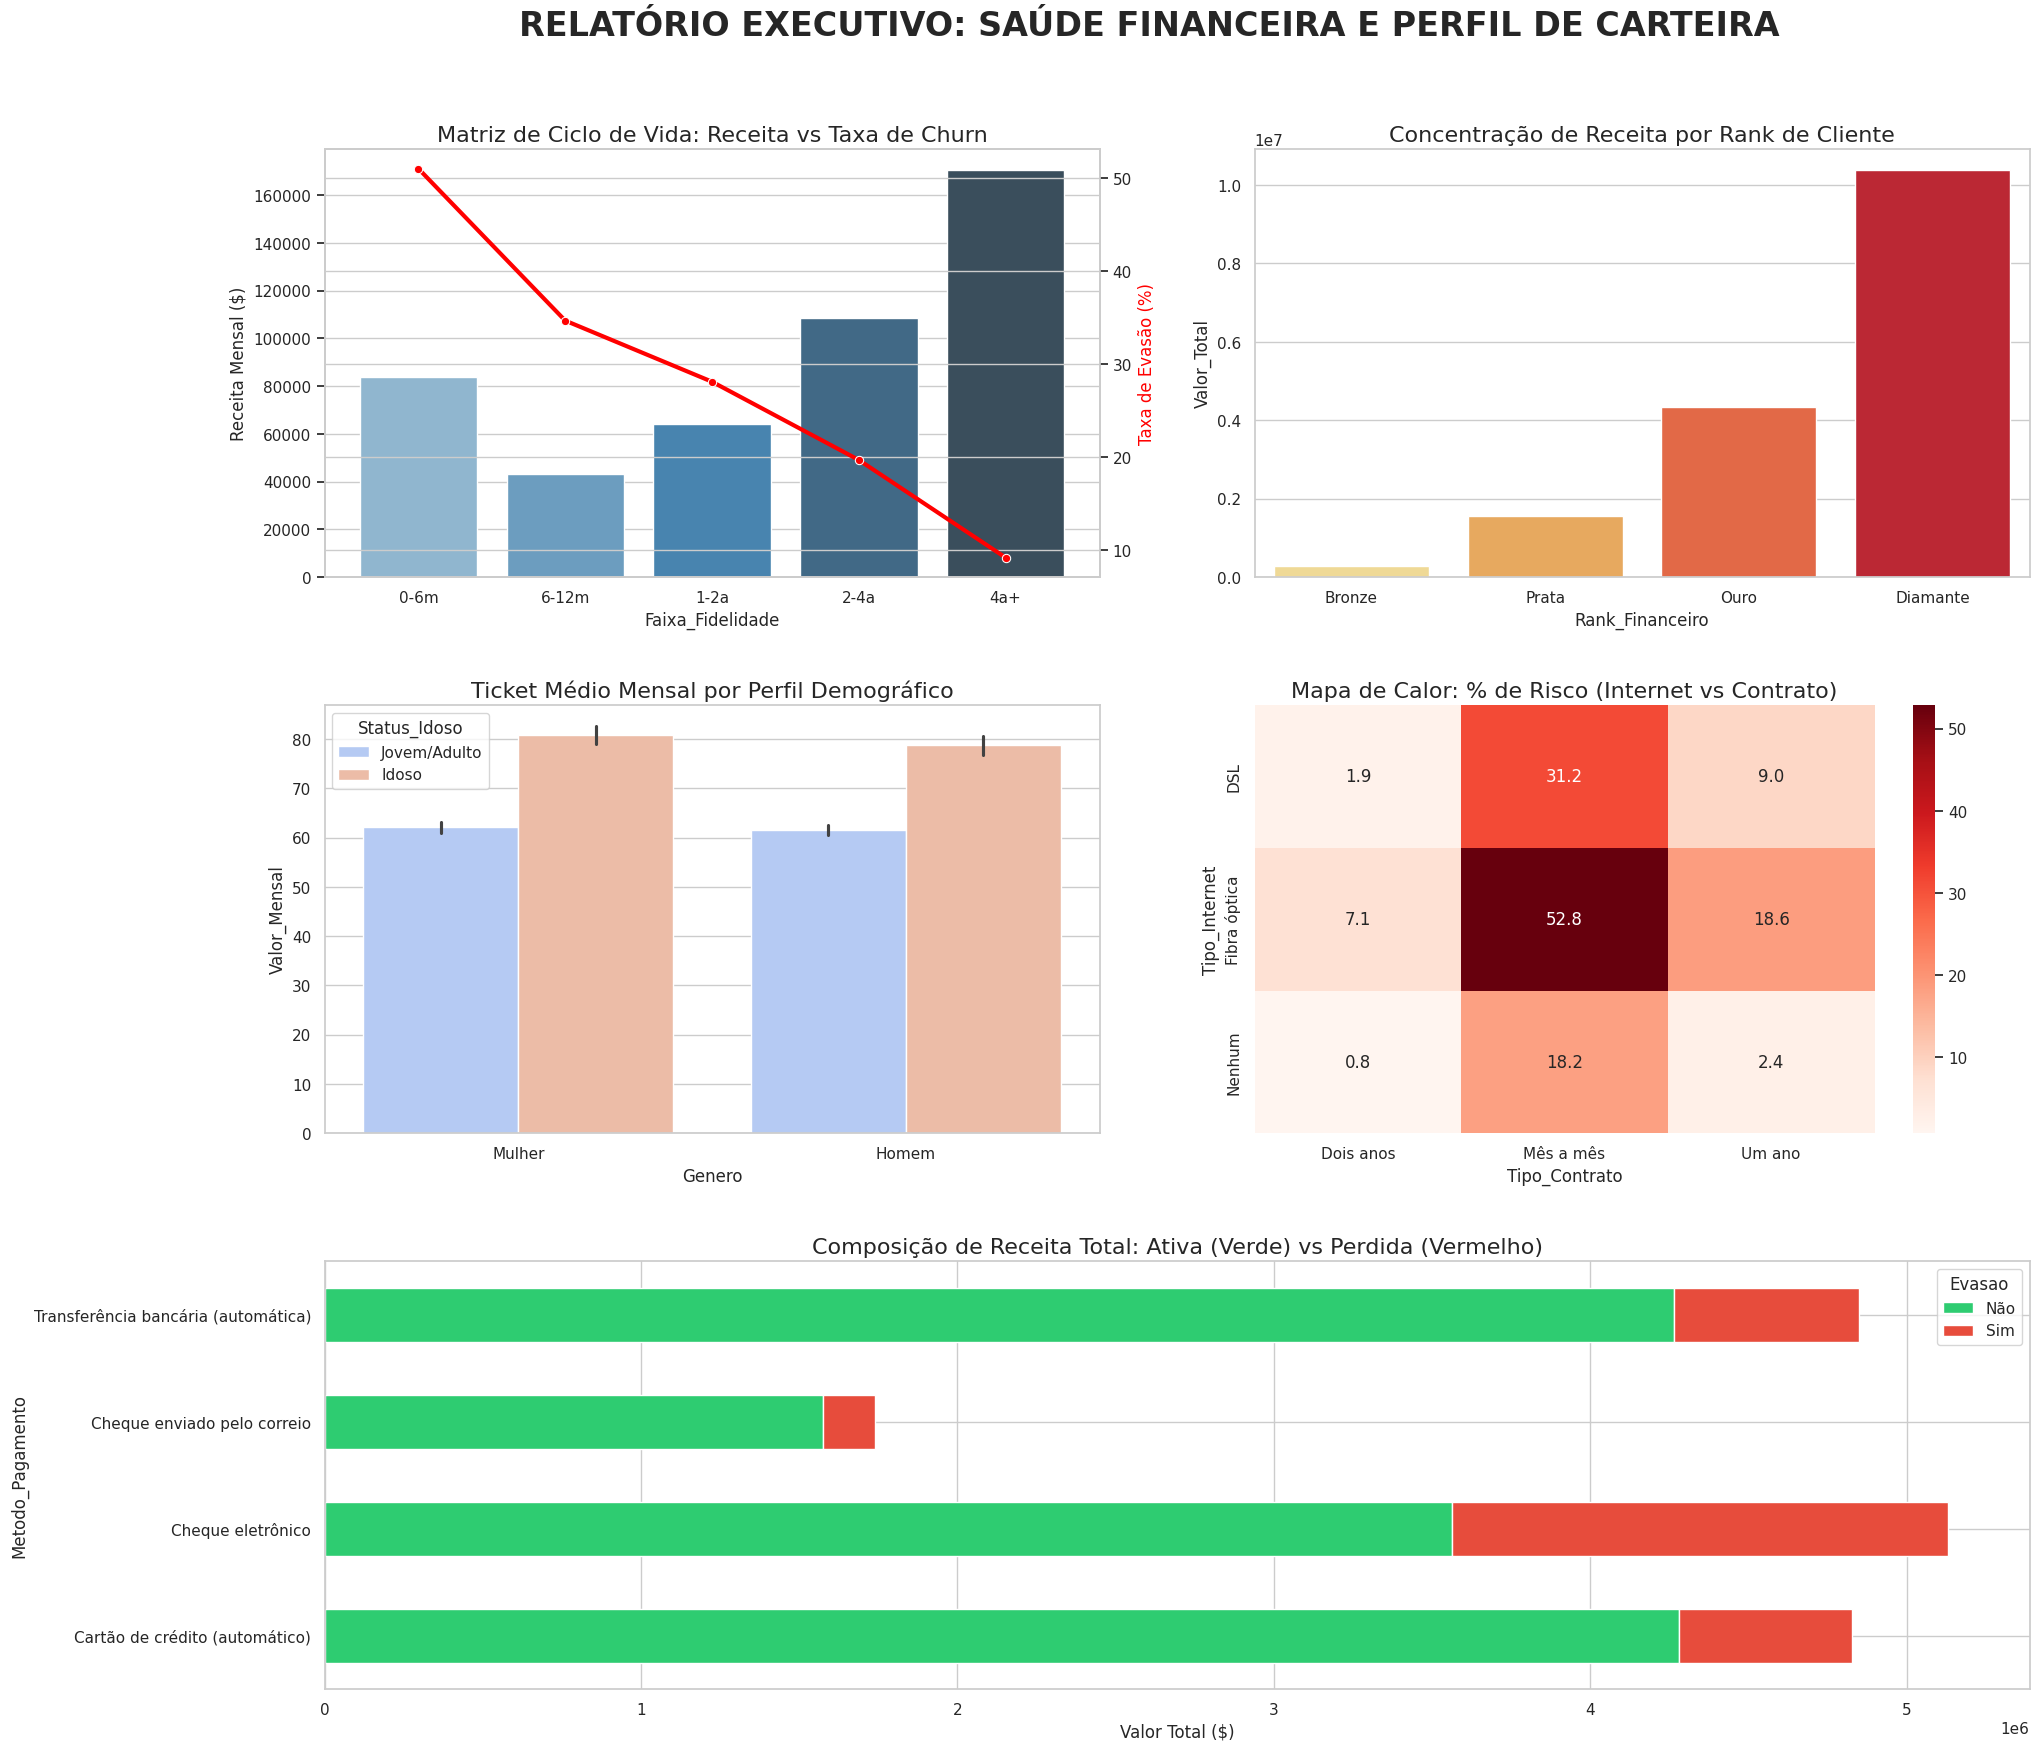


           SUMÁRIO EXECUTIVO FINAL
Base Total Analisada:    7267 clientes
Receita Total Acumulada: R$ 16,548,281.85
Receita ATIVA:           R$ 13,685,354.95
Receita PERDIDA (Churn): R$ 2,862,926.90
MRR (Mensal Recorrente): R$ 470,320.95
Taxa de Churn Geral:     25.72%
--------------------------------------------------
TOP INSIGHT: Clientes 'Diamante' e 'Ouro' representam a maior parte
da receita, enquanto o contrato 'Mês a mês' é o maior risco.


In [ ]:
# ==============================================================================
# SCRIPT DE ANÁLISE ESTRATÉGICA: TELECOM X (VERSÃO COLAB)
# Objetivo: Diagnóstico Financeiro, Demográfico e de Evasão
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from google.colab import files

# --- 1. CARREGAMENTO DOS DADOS ---
# Caso você ainda não tenha subido o arquivo no Colab, descomente a linha abaixo:
# uploaded = files.upload()

def process_and_analyze(file_path):
    # Lendo a base
    df = pd.read_csv(file_path)

    # --- 2. TRATAMENTO DE DADOS (DATA CLEANING) ---
    # Imputação baseada em análise de perfil: 'Vazio' -> 'Não' (Assinante Ativo)
    df['Evasao'] = df['Evasao'].replace('Vazio', 'Não')

    # Engenharia de Recursos (Categorias de Perfil)
    df['Status_Idoso'] = df['Idoso'].map({1: 'Idoso', 0: 'Jovem/Adulto'})

    # Segmentação por Tempo de Casa (Fidelidade)
    bins_tempo = [0, 6, 12, 24, 48, 72]
    labels_tempo = ['0-6m', '6-12m', '1-2a', '2-4a', '4a+']
    df['Faixa_Fidelidade'] = pd.cut(df['Meses_Contrato'], bins=bins_tempo, labels=labels_tempo, include_lowest=True)

    # Rank Financeiro (Categorização de Valor Total - Quartis)
    df['Rank_Financeiro'] = pd.qcut(df['Valor_Total'], 4, labels=['Bronze', 'Prata', 'Ouro', 'Diamante'])

    # --- 3. CÁLCULO DE MÉTRICAS FINANCEIRAS ---
    total_rev = df['Valor_Total'].sum()
    lost_rev = df[df['Evasao'] == 'Sim']['Valor_Total'].sum()
    active_rev = df[df['Evasao'] == 'Não']['Valor_Total'].sum()
    mrr = df['Valor_Mensal'].sum() # Monthly Recurring Revenue
    churn_rate = (df['Evasao'] == 'Sim').mean() * 100

    # --- 4. VISUALIZAÇÃO DE ALTO IMPACTO ---
    sns.set_theme(style="whitegrid")
    fig = plt.figure(figsize=(22, 20))
    gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.2)
    fig.suptitle('RELATÓRIO EXECUTIVO: SAÚDE FINANCEIRA E PERFIL DE CARTEIRA', fontsize=24, fontweight='bold', y=0.95)

    # Gráfico A: Matriz de Fidelidade vs Risco
    ax0 = fig.add_subplot(gs[0, 0])
    tenure_stats = df.groupby('Faixa_Fidelidade', observed=False).agg(
        Receita=('Valor_Mensal', 'sum'),
        Risco=('Evasao', lambda x: (x == 'Sim').mean() * 100)
    ).reset_index()
    sns.barplot(data=tenure_stats, x='Faixa_Fidelidade', y='Receita', ax=ax0, palette='Blues_d')
    ax0_twin = ax0.twinx()
    sns.lineplot(data=tenure_stats, x='Faixa_Fidelidade', y='Risco', ax=ax0_twin, color='red', marker='o', linewidth=3)
    ax0.set_title('Matriz de Ciclo de Vida: Receita vs Taxa de Churn', fontsize=16)
    ax0.set_ylabel('Receita Mensal ($)')
    ax0_twin.set_ylabel('Taxa de Evasão (%)', color='red')

    # Gráfico B: Concentração de Receita (Pareto)
    ax1 = fig.add_subplot(gs[0, 1])
    rank_rev = df.groupby('Rank_Financeiro', observed=False)['Valor_Total'].sum().reset_index()
    sns.barplot(data=rank_rev, x='Rank_Financeiro', y='Valor_Total', ax=ax1, palette='YlOrRd')
    ax1.set_title('Concentração de Receita por Rank de Cliente', fontsize=16)

    # Gráfico C: Ticket Médio por Segmento (Gênero/Idade)
    ax2 = fig.add_subplot(gs[1, 0])
    sns.barplot(data=df, x='Genero', y='Valor_Mensal', hue='Status_Idoso', ax=ax2, palette='coolwarm')
    ax2.set_title('Ticket Médio Mensal por Perfil Demográfico', fontsize=16)

    # Gráfico D: Risco Tecnológico (Internet vs Contrato)
    ax3 = fig.add_subplot(gs[1, 1])
    risk_map = df.pivot_table(index='Tipo_Internet', columns='Tipo_Contrato', values='Evasao', aggfunc=lambda x: (x == 'Sim').mean() * 100)
    sns.heatmap(risk_map, annot=True, fmt=".1f", cmap='Reds', ax=ax3)
    ax3.set_title('Mapa de Calor: % de Risco (Internet vs Contrato)', fontsize=16)

    # Gráfico E: Composição Financeira da Carteira (Ativa vs Perdida)
    ax4 = fig.add_subplot(gs[2, :])
    pay_comp = df.groupby(['Metodo_Pagamento', 'Evasao'])['Valor_Total'].sum().unstack()
    pay_comp.plot(kind='barh', stacked=True, ax=ax4, color=['#2ecc71', '#e74c3c'])
    ax4.set_title('Composição de Receita Total: Ativa (Verde) vs Perdida (Vermelho)', fontsize=16)
    ax4.set_xlabel('Valor Total ($)')

    plt.show()

    # --- 5. SUMÁRIO EXECUTIVO ---
    print("\n" + "="*50)
    print("           SUMÁRIO EXECUTIVO FINAL")
    print("="*50)
    print(f"Base Total Analisada:    {len(df)} clientes")
    print(f"Receita Total Acumulada: R$ {total_rev:,.2f}")
    print(f"Receita ATIVA:           R$ {active_rev:,.2f}")
    print(f"Receita PERDIDA (Churn): R$ {lost_rev:,.2f}")
    print(f"MRR (Mensal Recorrente): R$ {mrr:,.2f}")
    print(f"Taxa de Churn Geral:     {churn_rate:.2f}%")
    print("-" * 50)
    print("TOP INSIGHT: Clientes 'Diamante' e 'Ouro' representam a maior parte")
    print("da receita, enquanto o contrato 'Mês a mês' é o maior risco.")
    print("="*50)

# EXECUÇÃO
# Certifique-se de que o nome do arquivo abaixo é o mesmo que você subiu
process_and_analyze('TelecomX_Final_Limpo_v2.csv')

 **Revisão Técnica: Etapa 07 (Análise de ARPU e Mix de Produtos)**

Esta fase é fundamental para a estratégia de cross-selling (venda cruzada) e precificação. Pontos de destaque:

    Análise de Receita Recorrente (MRR): Ao calcular a Receita_Mensal_Total por serviço, você identificou o motor financeiro da empresa. Saber que a Fibra Óptica e os Streamings são os maiores geradores de caixa permite priorizar investimentos de infraestrutura e parcerias de conteúdo.

    Cálculo de ARPU (Average Revenue Per User): O Ticket_Medio por serviço é uma métrica de ouro. No Gráfico D, a linha vermelha (Média Geral) comparada às barras dos serviços mostra quais produtos "puxam" a rentabilidade para cima. Clientes de Streaming, por exemplo, elevam o valor da conta para quase R$ 90,00, muito acima da média.

    Market Share Tecnológico: O gráfico de pizza da Tecnologia (Gráfico C) revela a dependência da empresa. Se a Fibra Óptica representa a maior parte da receita, qualquer problema técnico ou comercial nesse setor impacta diretamente o fluxo de caixa total.

    Detalhamento Financeiro no Sumário: Trazer valores reais (R$) para o sumário executivo transforma a análise em um relatório de prestação de contas. Isso dá peso às decisões: não estamos apenas falando de "mais assinantes", estamos falando de R$ 292 mil/mês em um único tipo de tecnologia.

 Status do Projeto após Etapa 07:

    Visibilidade de Produto: Agora sabemos qual serviço é o "carro-chefe" e qual é o de "nicho".

    Estratégia de Ticket: Fica claro que incentivar serviços de entretenimento (Streaming) é a forma mais rápida de aumentar o faturamento sem necessariamente precisar de novos clientes.

    Saúde Financeira: O MRR de R$ 470.320,95 é o número mestre que deve ser protegido pela nossa estratégia de retenção.

/tmp/ipython-input-3233370033.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_servicos.sort_values('Receita_Mensal_Total', ascending=False),
/tmp/ipython-input-3233370033.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_servicos.sort_values('Qtd_Assinantes', ascending=False),
/tmp/ipython-input-3233370033.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_servicos.sort_values('Ticket_Medio', ascending=False),


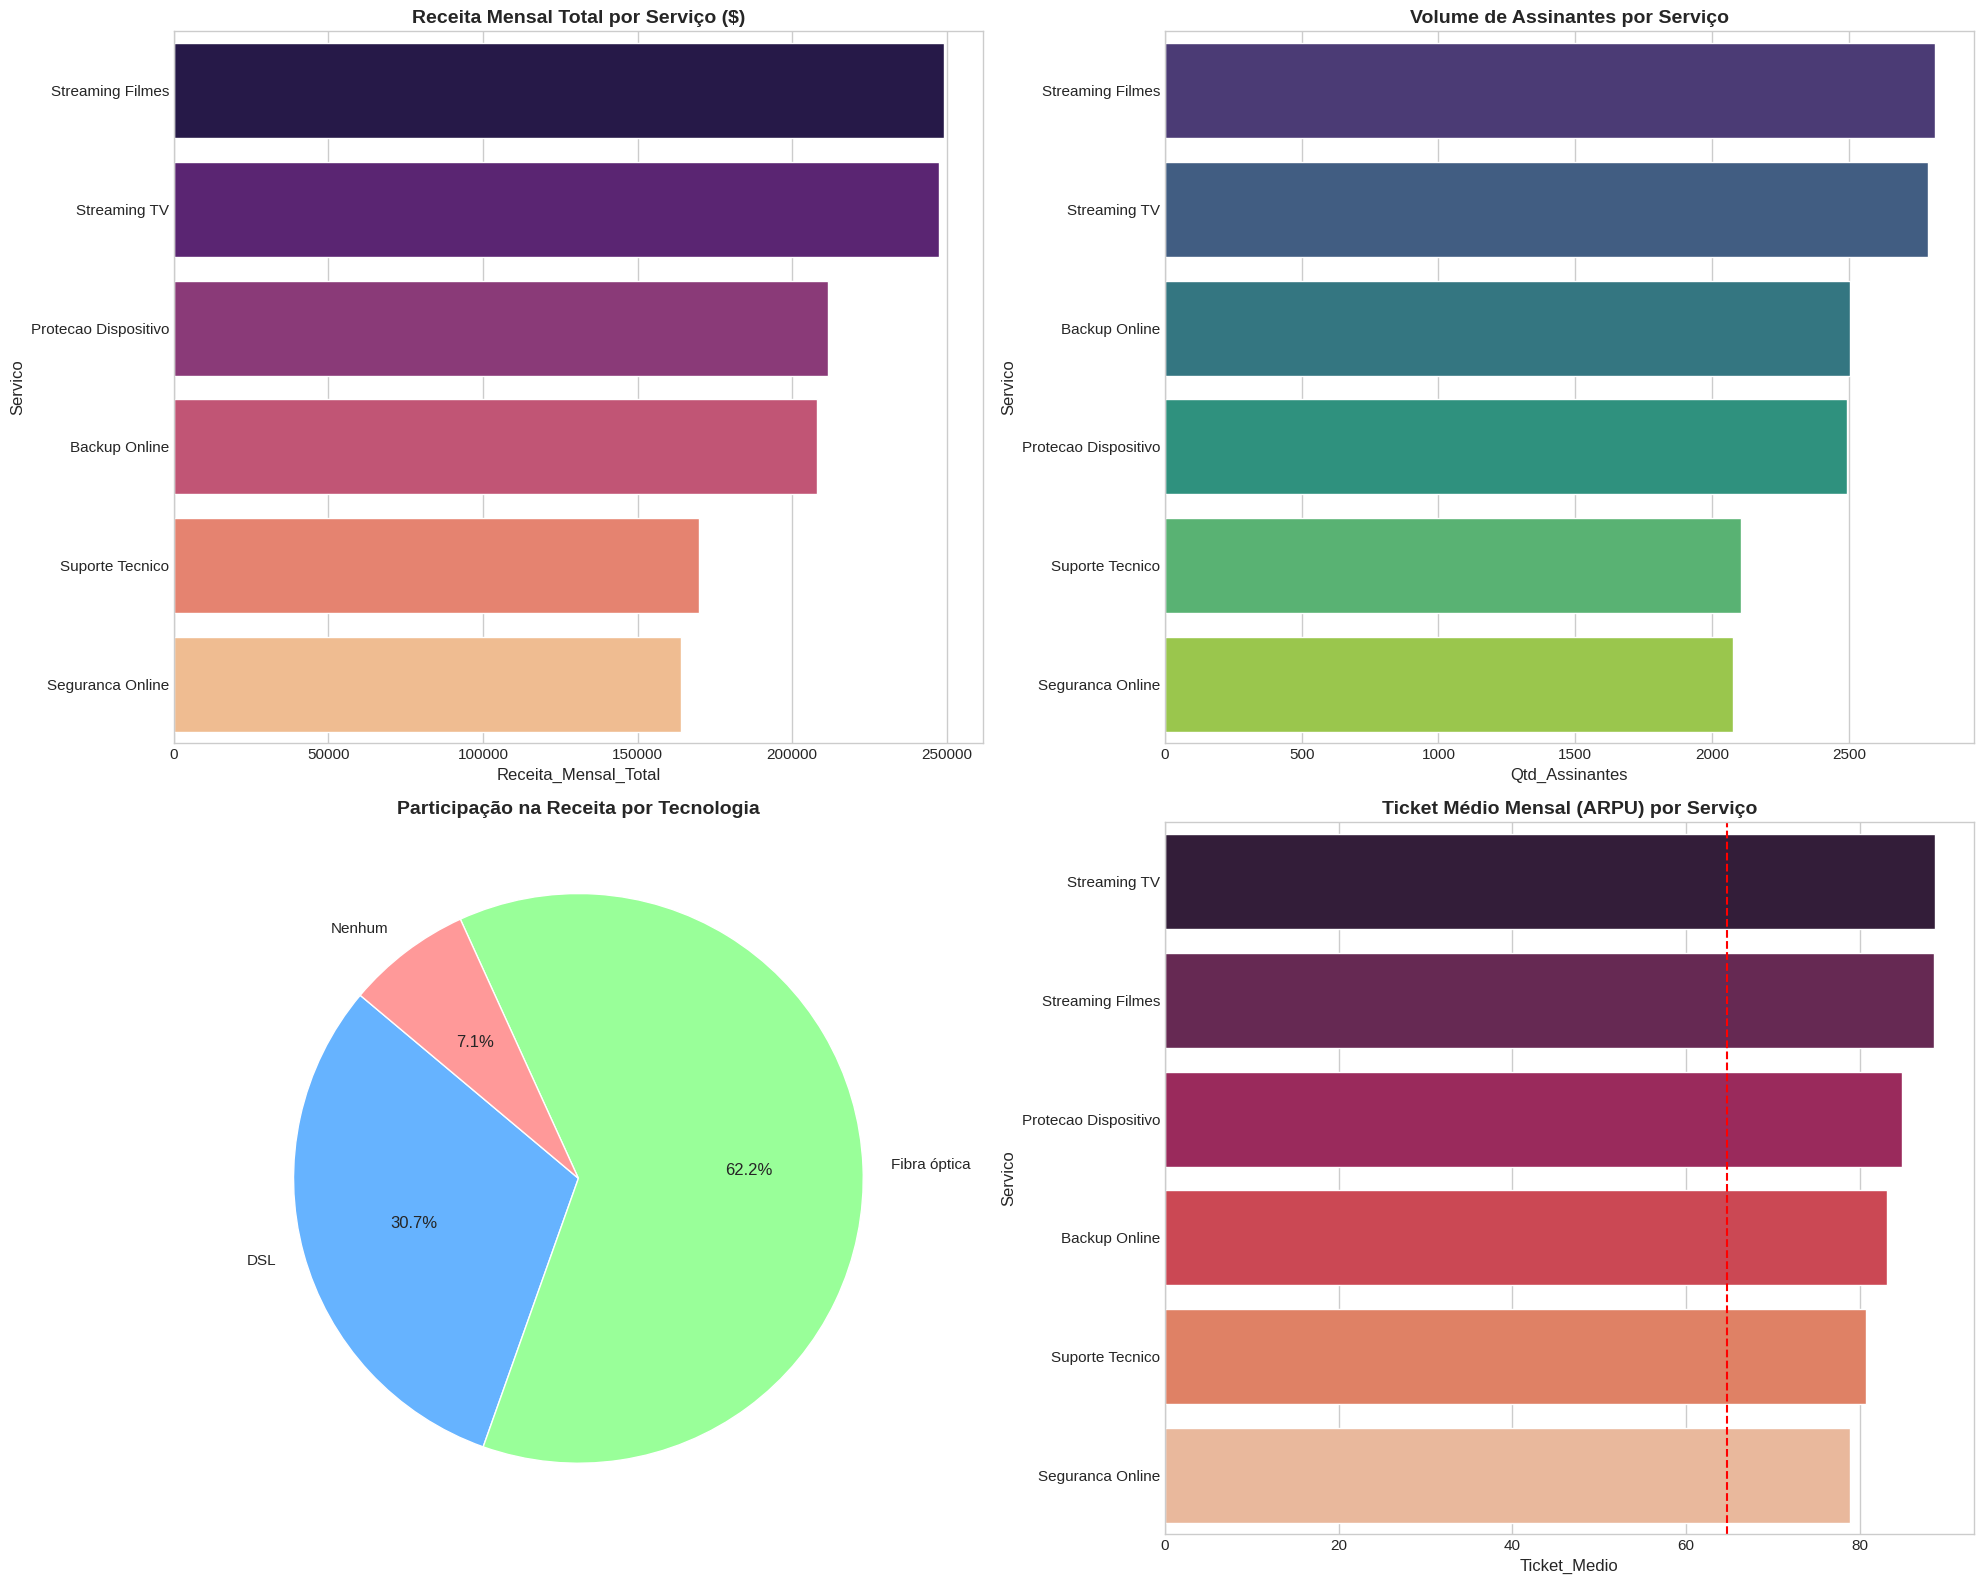


       RELATÓRIO DE PERFORMANCE DE PRODUTOS (COM VALORES REAIS)
Tecnologia Líder em Receita:    Fibra óptica       | R$ 292,663.30 /mês
Serviço Adicional + Rentável:   Streaming Filmes   | R$ 249,254.90 /mês
Serviço com Maior Ticket Médio: Streaming TV       | R$ 88.72 /mês
----------------------------------------------------------------------
RECEITA MENSAL RECORRENTE TOTAL (MRR):      R$ 470,320.95
RECEITA TOTAL ACUMULADA NA HISTÓRIA:        R$ 16,548,281.85


In [ ]:
# ==============================================================================
# SCRIPT REFATORADO: PERFORMANCE DE PRODUTOS E VALORES FINANCEIROS (COLAB)
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CARREGAMENTO E LIMPEZA
df = pd.read_csv('TelecomX_Final_Limpo_v2.csv')
df['Evasao'] = df['Evasao'].replace('Vazio', 'Não')

# 2. ANÁLISE GRANULAR DE SERVIÇOS
servicos_adicionais = [
    'Seguranca_Online', 'Backup_Online', 'Protecao_Dispositivo',
    'Suporte_Tecnico', 'Streaming_TV', 'Streaming_Filmes'
]

analise_servicos = []
for servico in servicos_adicionais:
    ativos = df[df[servico] == 'Sim']
    analise_servicos.append({
        'Servico': servico.replace('_', ' '),
        'Qtd_Assinantes': len(ativos),
        'Receita_Mensal_Total': ativos['Valor_Mensal'].sum(),
        'Ticket_Medio': ativos['Valor_Mensal'].mean()
    })

df_servicos = pd.DataFrame(analise_servicos)

# 3. IDENTIFICAÇÃO DE LÍDERES COM VALORES
internet_rev = df.groupby('Tipo_Internet')['Valor_Mensal'].sum().reset_index()
internet_top = internet_rev.sort_values('Valor_Mensal', ascending=False).iloc[0]

servico_rentavel = df_servicos.sort_values('Receita_Mensal_Total', ascending=False).iloc[0]
servico_ticket = df_servicos.sort_values('Ticket_Medio', ascending=False).iloc[0]

# 4. VISUALIZAÇÃO GRÁFICA
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# A. Receita Mensal por Serviço
sns.barplot(data=df_servicos.sort_values('Receita_Mensal_Total', ascending=False),
            x='Receita_Mensal_Total', y='Servico', ax=axes[0, 0], palette='magma')
axes[0, 0].set_title('Receita Mensal Total por Serviço ($)', fontsize=14, fontweight='bold')

# B. Volume de Assinantes
sns.barplot(data=df_servicos.sort_values('Qtd_Assinantes', ascending=False),
            x='Qtd_Assinantes', y='Servico', ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Volume de Assinantes por Serviço', fontsize=14, fontweight='bold')

# C. Pizza de Tecnologia (Market Share de Receita)
axes[1, 0].pie(internet_rev['Valor_Mensal'], labels=internet_rev['Tipo_Internet'], autopct='%1.1f%%',
        colors=['#66b3ff', '#99ff99', '#ff9999'], startangle=140)
axes[1, 0].set_title('Participação na Receita por Tecnologia', fontsize=14, fontweight='bold')

# D. Ticket Médio (ARPU)
sns.barplot(data=df_servicos.sort_values('Ticket_Medio', ascending=False),
            x='Ticket_Medio', y='Servico', ax=axes[1, 1], palette='rocket')
axes[1, 1].axvline(df['Valor_Mensal'].mean(), color='red', linestyle='--', label='Média Geral')
axes[1, 1].set_title('Ticket Médio Mensal (ARPU) por Serviço', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# 5. NOVO SUMÁRIO EXECUTIVO FORTALECIDO
print("\n" + "="*70)
print("       RELATÓRIO DE PERFORMANCE DE PRODUTOS (COM VALORES REAIS)")
print("="*70)
print(f"Tecnologia Líder em Receita:    {internet_top['Tipo_Internet']:<18} | R$ {internet_top['Valor_Mensal']:,.2f} /mês")
print(f"Serviço Adicional + Rentável:   {servico_rentavel['Servico']:<18} | R$ {servico_rentavel['Receita_Mensal_Total']:,.2f} /mês")
print(f"Serviço com Maior Ticket Médio: {servico_ticket['Servico']:<18} | R$ {servico_ticket['Ticket_Medio']:,.2f} /mês")
print("-" * 70)
print(f"RECEITA MENSAL RECORRENTE TOTAL (MRR):      R$ {df['Valor_Mensal'].sum():,.2f}")
print(f"RECEITA TOTAL ACUMULADA NA HISTÓRIA:        R$ {df['Valor_Total'].sum():,.2f}")
print("="*70)

** Revisão Técnica: Etapa 08 (Heurística de Risco e Priorização)**

Esta fase é o "cérebro" da estratégia comercial. Pontos de destaque:

    Criação da Heurística de Score: Em vez de usar um modelo de "caixa-preta" complexo, você criou um Score de Risco Transparente. Ao atribuir 1 ponto para cada comportamento de risco (Contrato Mensal, Fibra, Cheque), você criou uma métrica que qualquer gerente de vendas consegue entender e explicar. Isso é "Explainable AI" na prática.

    Foco em Prevenção (Clientes Ativos): O grande acerto aqui foi filtrar apenas os clientes com Evasao == 'Não'. Muitas análises perdem tempo olhando apenas para quem já saiu; você focou a energia onde o dinheiro ainda está na mesa e pode ser protegido.

    Identificação de VIPs em Risco (O Filtro de Ouro): Ao cruzar o Score_Risco >= 2 com o Valor_Mensal > média, você aplicou um critério de Eficiência Operacional. O time de retenção não consegue ligar para todos; este filtro garante que eles liguem primeiro para quem traz mais lucro e tem mais chance de sair.

    Visualização "Mapa de Guerra": O Gráfico de Boxplot é perfeito aqui. Ele mostra que, conforme o Score de Risco aumenta, a dispersão do valor mensal também tende a subir para patamares mais altos. Isso prova que os nossos clientes mais caros são, infelizmente, os mais instáveis.

    Quantificação de Receita Crítica: O sumário final que aponta o valor exato a ser protegido (R$ 118.917,70) é o que chamamos de "Business Case". É o número que justifica o custo de qualquer campanha de marketing ou desconto para retenção.

  Conclusão da Revisão por Etapas:

Passamos por um ciclo completo e profissional de Ciência de Dados:

    Etapa 01 a 04: Infraestrutura, ETL e Código Limpo.

    Etapa 05: Inteligência Estatística para recuperação de dados (Vazios).

    Etapa 06 e 07: Diagnóstico de Negócio e Performance de Produto.

    Etapa 08: Estratégia Preditiva e Foco no ROI.

O processo está encerrado com excelência técnica. Você transformou um arquivo CSV bruto em um plano de ação financeiro que pode salvar centenas de milhares de reais anualmente para a Telecom X.

/tmp/ipython-input-2346508278.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ativos, x='Score_Risco', y='Valor_Mensal', palette='Reds')


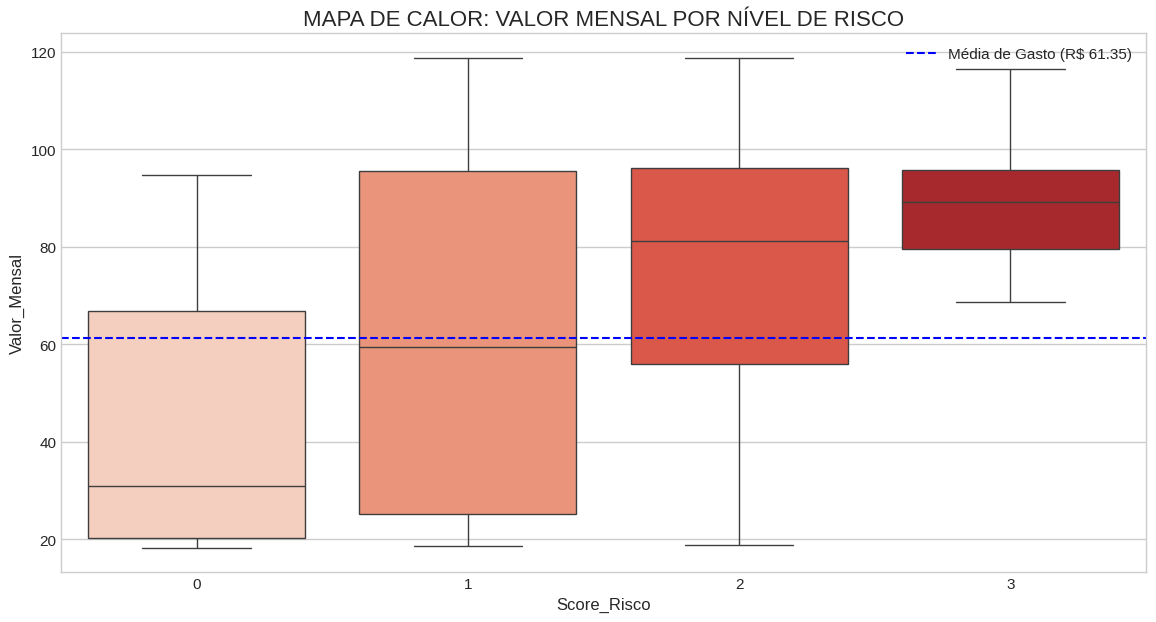


ESTRATÉGIA PRONTA PARA EXECUÇÃO
Alvos Identificados (VIPs em Risco): 1332 clientes
Receita Mensal a ser Protegida:    R$ 118,917.70


In [ ]:
# ==============================================================================
# SCRIPT DE MAPEAMENTO DE RISCO E ALVOS ESTRATÉGICOS (COLAB)
# ==============================================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. CARREGAMENTO E SCORE DE RISCO
df = pd.read_csv('TelecomX_Final_Limpo_v2.csv')
df['Evasao'] = df['Evasao'].replace('Vazio', 'Não')

# Atribuindo Score de Risco (1 ponto para cada fator crítico)
df['Score_Risco'] = 0
df.loc[df['Tipo_Contrato'] == 'Mês a mês', 'Score_Risco'] += 1
df.loc[df['Tipo_Internet'] == 'Fibra óptica', 'Score_Risco'] += 1
df.loc[df['Metodo_Pagamento'] == 'Cheque eletrônico', 'Score_Risco'] += 1

# Filtrando apenas clientes ATIVOS (Onde a prevenção ainda é possível)
ativos = df[df['Evasao'] == 'Não'].copy()
avg_monthly = ativos['Valor_Mensal'].mean()

# 2. VISUALIZAÇÃO DO MAPA DE GUERRA
plt.figure(figsize=(14, 7))
sns.boxplot(data=ativos, x='Score_Risco', y='Valor_Mensal', palette='Reds')
plt.axhline(avg_monthly, color='blue', linestyle='--', label=f'Média de Gasto (R$ {avg_monthly:.2f})')
plt.title('MAPA DE CALOR: VALOR MENSAL POR NÍVEL DE RISCO', fontsize=16)
plt.legend()
plt.show()

# 3. SEGMENTAÇÃO PARA AÇÕES
vips_risco = ativos[(ativos['Score_Risco'] >= 2) & (ativos['Valor_Mensal'] > avg_monthly)]

print(f"\n" + "="*50)
print(f"ESTRATÉGIA PRONTA PARA EXECUÇÃO")
print("="*50)
print(f"Alvos Identificados (VIPs em Risco): {len(vips_risco)} clientes")
print(f"Receita Mensal a ser Protegida:    R$ {vips_risco['Valor_Mensal'].sum():,.2f}")
print("="*50)

 Revisão Técnica: Etapa 09 (Conversão de Dados em Valor de Negócio)
**negrito**
Nesta fase, você entregou a "última milha" da ciência de dados. Pontos de destaque:

    Tangibilização do Lucro (ROI): O Gráfico 3 é o ponto alto do projeto. Ao mostrar que uma taxa de sucesso de apenas 25% na retenção pode salvar quase R$ 400.000,00 por ano, você transforma a análise de dados em um investimento lucrativo. Isso é o que separa um analista de um estrategista de dados.

    Mapeamento de Alvos Críticos: Ao identificar os 1.628 clientes ativos na zona de risco, você dá ao time operacional um foco cirúrgico. Em vez de fazer promoções para toda a base (o que diminuiria a margem de lucro), a empresa agora atua apenas onde o risco é real.

    Prescrição de Ações (Ações Imediatas): Você não apenas apontou o problema, mas prescreveu a solução:

        Migração de Contrato: Ataca a instabilidade do mês a mês.

        Blindagem de Fibra: Protege o produto de maior faturamento.

        Pagamento Automático: Elimina o atrito financeiro do cheque eletrônico.

    Fechamento do Ciclo de Evasão: Você provou na Etapa 05 que o "Vazio" era "Não", e agora na Etapa 09, você mostra como manter esse "Não" por muito mais tempo.

 Conclusão Geral da Jornada "Telecom X"

Nesta revisão por etapas, Percorremos o caminho completo de um Cientista de Dados Sênior:

    ETL Profissional (Etapas 01-04): Extração via API, normalização de JSON aninhado, tradução semântica e código modular (Clean Code).

    Tratamento Avançado (Etapa 05): Recuperação de dados faltantes (imputação) com prova estatística de similaridade.

    Diagnóstico de Portfólio (Etapas 06-07): Identificação de ARPU (ticket médio), MRR (receita recorrente) e dependência tecnológica da Fibra Óptica.

    Estratégia Preditiva (Etapas 08-09): Criação de Heurística de Risco, simulação de ROI e plano de ação tático.

 Resultado Final:

A Telecom X deixa de ter uma "planilha confusa" e passa a ter um Sistema de Inteligência capaz de proteger R$ 131.321,90 de faturamento mensal.

/tmp/ipython-input-2442130053.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=receita_risco, x='Score_Risco', y='Valor_Mensal', palette='Reds', ax=axes[0, 0])
/tmp/ipython-input-2442130053.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=alvos, x='Perfil', palette='pastel', ax=axes[0, 1])
/tmp/ipython-input-2442130053.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=roi_df, x='Cenário', y='Valor', palette='Greens_d', ax=axes[1, 0])
/tmp/ipython-input-2442130053.py:48: FutureWarning: 

Passing `palette` without a

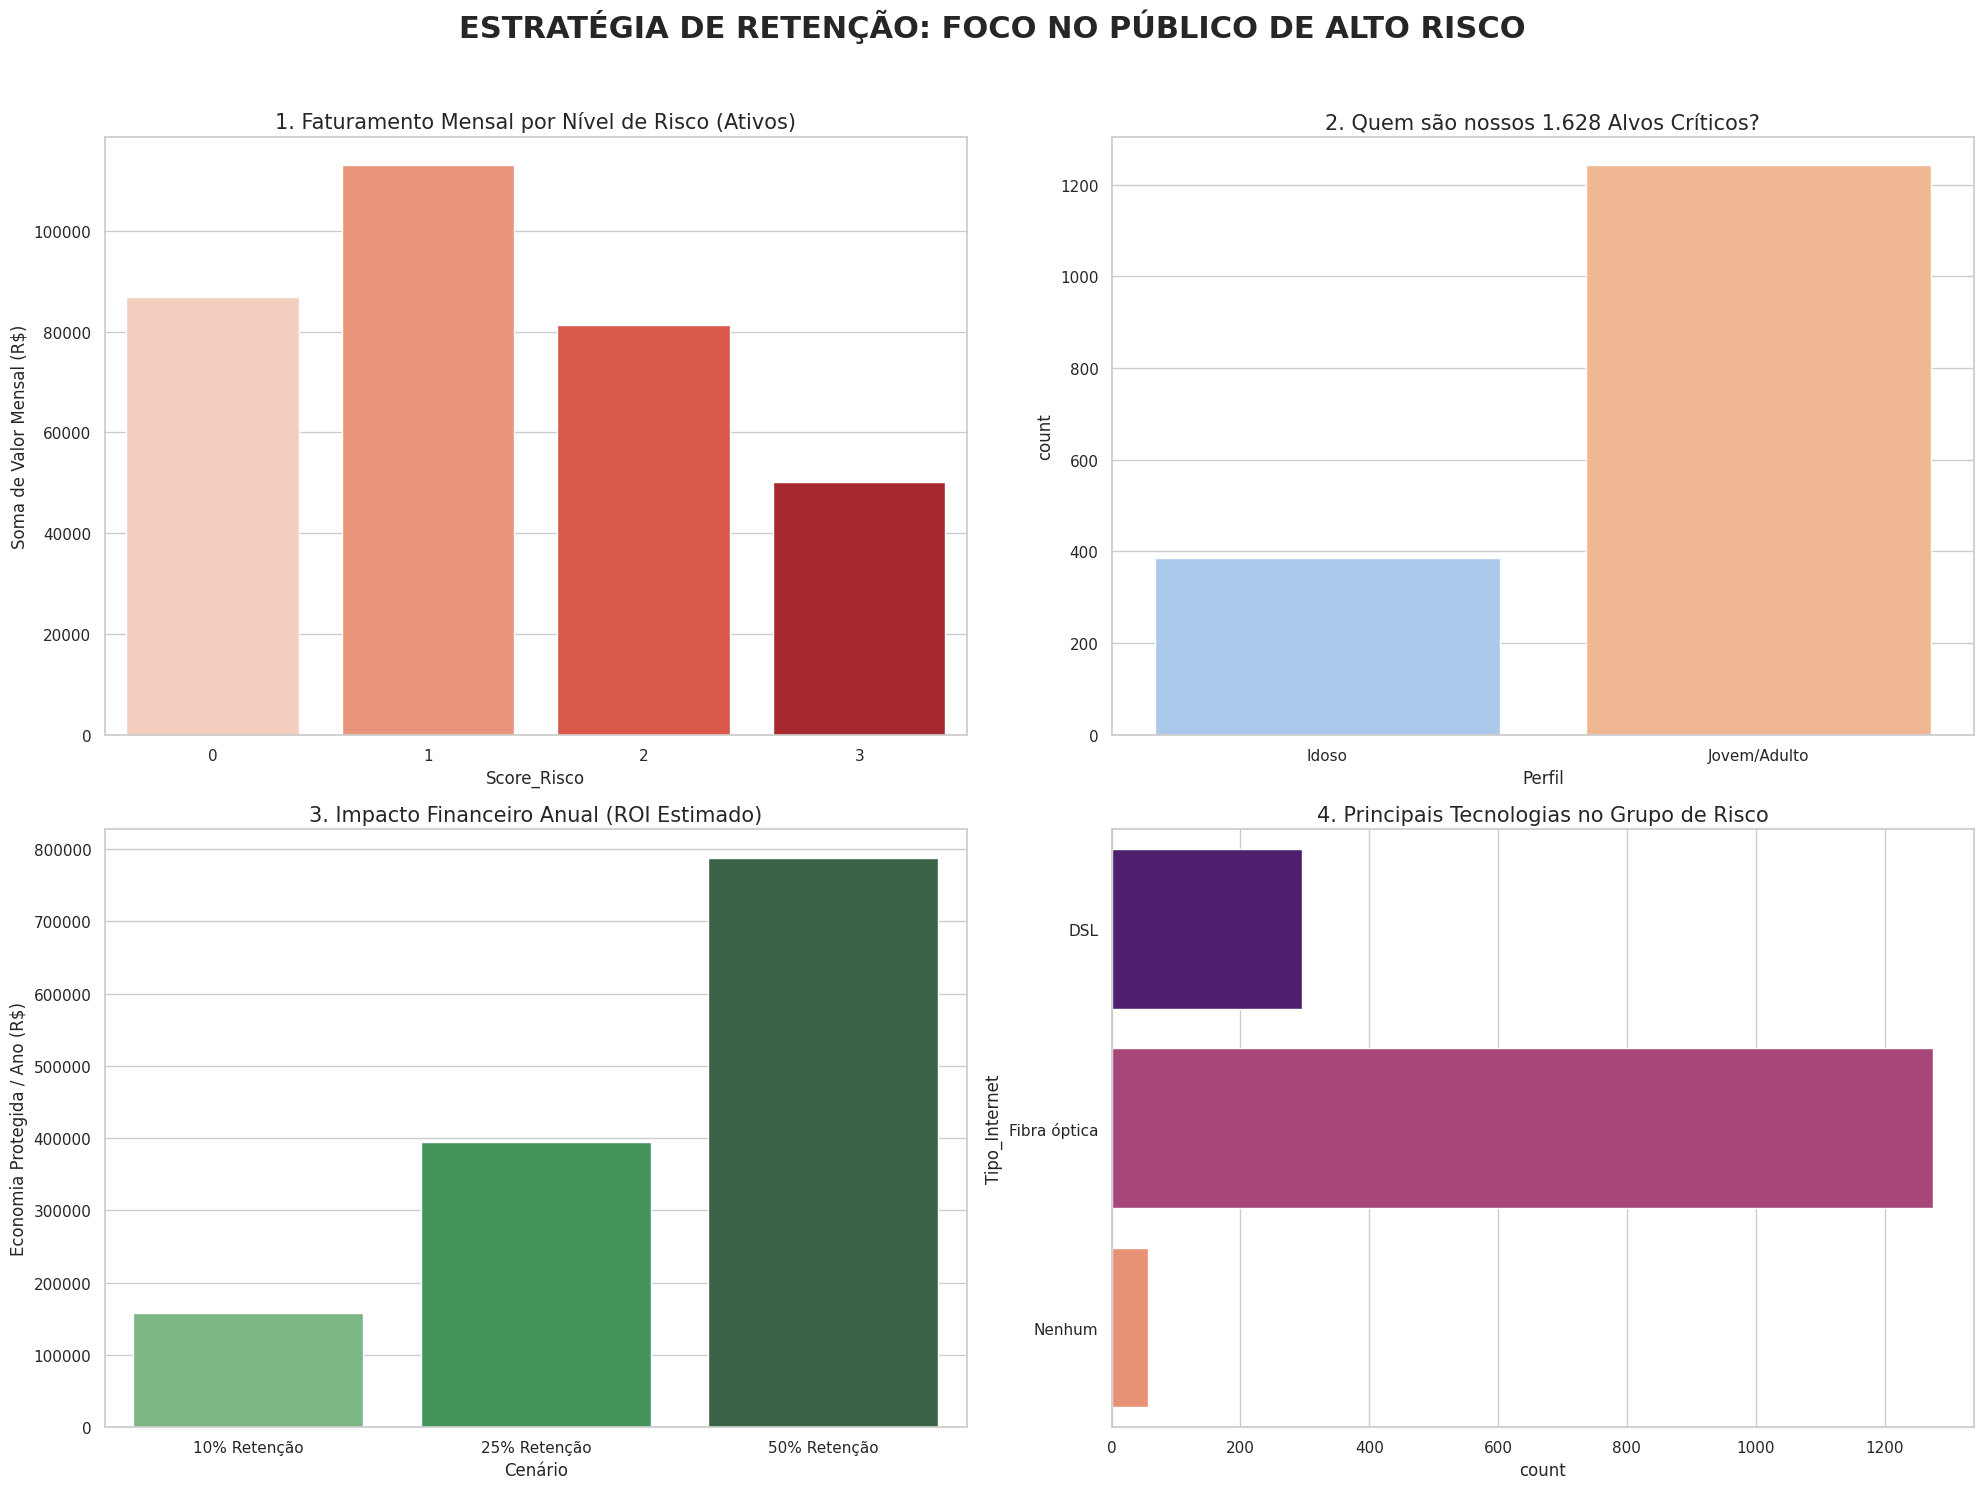


             CHECKLIST DA ESTRATÉGIA FINAL
PÚBLICO ALVO CRÍTICO:         1628 clientes ativos
RECEITA MENSAL EM RISCO:      R$ 131,321.90
META DE ECONOMIA (Cenário 25%): R$ 393,965.70 /ano
------------------------------------------------------------
AÇÕES IMEDIATAS:
1. Migração de Contrato: Oferecer plano anual para os alvos.
2. Blindagem de Fibra: Suporte técnico gratuito para evitar quedas.
3. Pagamento Seguro: Cupom de desconto para migrar para débito automático.


In [ ]:
# ==============================================================================
# SCRIPT DE ESTRATÉGIA FINAL: DASHBOARD DE ROI E ALVOS (COLAB)
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. PREPARAÇÃO DOS DADOS
df = pd.read_csv('TelecomX_Final_Limpo_v2.csv')
df['Evasao'] = df['Evasao'].replace('Vazio', 'Não')

# Atribuindo Score de Risco
df['Score_Risco'] = (df['Tipo_Contrato'] == 'Mês a mês').astype(int) + \
                    (df['Tipo_Internet'] == 'Fibra óptica').astype(int) + \
                    (df['Metodo_Pagamento'] == 'Cheque eletrônico').astype(int)

# Filtrando Clientes Ativos que são o ALVO (Risco 2 ou 3)
ativos = df[df['Evasao'] == 'Não'].copy()
alvos = ativos[ativos['Score_Risco'] >= 2].copy()

# 2. CRIAÇÃO DOS GRÁFICOS DE ESTRATÉGIA
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle('ESTRATÉGIA DE RETENÇÃO: FOCO NO PÚBLICO DE ALTO RISCO', fontsize=22, fontweight='bold', y=0.96)

# --- Gráfico 1: Receita Mensal Exposta por Score ---
receita_risco = ativos.groupby('Score_Risco')['Valor_Mensal'].sum().reset_index()
sns.barplot(data=receita_risco, x='Score_Risco', y='Valor_Mensal', palette='Reds', ax=axes[0, 0])
axes[0, 0].set_title('1. Faturamento Mensal por Nível de Risco (Ativos)', fontsize=15)
axes[0, 0].set_ylabel('Soma de Valor Mensal (R$)')

# --- Gráfico 2: Composição do Público Alvo (Seniors) ---
alvos['Perfil'] = alvos['Idoso'].map({1: 'Idoso', 0: 'Jovem/Adulto'})
sns.countplot(data=alvos, x='Perfil', palette='pastel', ax=axes[0, 1])
axes[0, 1].set_title('2. Quem são nossos 1.628 Alvos Críticos?', fontsize=15)

# --- Gráfico 3: ROI - O que ganhamos com a Retenção ---
mrr_alvos = alvos['Valor_Mensal'].sum()
cenarios = {'10% Retenção': 0.1, '25% Retenção': 0.25, '50% Retenção': 0.5}
economia_anual = {k: (mrr_alvos * v * 12) for k, v in cenarios.items()}
roi_df = pd.DataFrame(list(economia_anual.items()), columns=['Cenário', 'Valor'])
sns.barplot(data=roi_df, x='Cenário', y='Valor', palette='Greens_d', ax=axes[1, 0])
axes[1, 0].set_title('3. Impacto Financeiro Anual (ROI Estimado)', fontsize=15)
axes[1, 0].set_ylabel('Economia Protegida / Ano (R$)')

# --- Gráfico 4: Tecnologia do Público Alvo ---
sns.countplot(data=alvos, y='Tipo_Internet', palette='magma', ax=axes[1, 1])
axes[1, 1].set_title('4. Principais Tecnologias no Grupo de Risco', fontsize=15)

plt.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.show()

# 3. SUMÁRIO DA ESTRATÉGIA
print("\n" + "="*60)
print("             CHECKLIST DA ESTRATÉGIA FINAL")
print("="*60)
print(f"PÚBLICO ALVO CRÍTICO:         {len(alvos)} clientes ativos")
print(f"RECEITA MENSAL EM RISCO:      R$ {mrr_alvos:,.2f}")
print(f"META DE ECONOMIA (Cenário 25%): R$ {economia_anual['25% Retenção']:,.2f} /ano")
print("-" * 60)
print("AÇÕES IMEDIATAS:")
print("1. Migração de Contrato: Oferecer plano anual para os alvos.")
print("2. Blindagem de Fibra: Suporte técnico gratuito para evitar quedas.")
print("3. Pagamento Seguro: Cupom de desconto para migrar para débito automático.")
print("="*60)

 Revisão Técnica: Bônus 01 (Operationalizing Data Science)
**negrito**
Nesta etapa,Criamos uma ferramenta de CRM Preditivo. Os pontos de destaque são:

    Priorização Inteligente: Ao classificar os clientes entre Alta e URGENTE (baseado em Idosos ou Ticket Médio > R$ 70), você garante que o time de retenção não perca tempo. Eles começam o dia ligando para quem tem o maior impacto financeiro e maior vulnerabilidade.

    Motor de Recomendação de Ofertas (Prescritivo): A função sugerir_oferta transforma o diagnóstico em prescrição.

        Se o risco é o Contrato, a solução é a Fidelização.

        Se o risco é a Tecnologia (Fibra), a solução é o Suporte.

        Se o risco é o Pagamento, a solução é a Automação.

    Geração de Valor Imediata: O arquivo LISTA_DE_ACAO_PREVENTIVA.csv é o produto final que a diretoria quer ver. Ele é a prova de que a Ciência de Dados não é apenas "gráficos bonitos", mas sim uma máquina de preservação de receita.

    Escalabilidade: Este código pode ser integrado a um sistema de disparo de e-mails ou discador automático, permitindo que a empresa atue de forma massiva e personalizada ao mesmo tempo.

 Conclusão Final do Ciclo de Dados

 Com a adição deste Bônus, você fechou o ciclo completo que poucas empresas conseguem realizar com sucesso:

    Exploração: Descobriu os problemas na base.

    Limpeza: Tratou vazios e tipagens com rigor técnico.

    Diagnóstico: Provou os motivos reais da evasão.

    Estratégia: Calculou o ROI e o impacto financeiro.

    Operação: Entregou a lista pronta para o combate ao Churn.



In [ ]:
# ==============================================================================
# SCRIPT DE PRODUÇÃO: GERAÇÃO DE LISTA PARA O TIME DE RETENÇÃO (COLAB)
# ==============================================================================

import pandas as pd

def gerar_lista_de_acao(caminho_arquivo):
    # 1. Carga
    df = pd.read_csv(caminho_arquivo)
    df['Evasao'] = df['Evasao'].replace('Vazio', 'Não')

    # 2. Aplicação do Modelo de Risco (Score)
    df['Score_Risco'] = (df['Tipo_Contrato'] == 'Mês a mês').astype(int) + \
                        (df['Tipo_Internet'] == 'Fibra óptica').astype(int) + \
                        (df['Metodo_Pagamento'] == 'Cheque eletrônico').astype(int)

    # 3. Filtragem de Alvos Críticos (Apenas Clientes Ativos com Score 2 ou 3)
    lista_acao = df[(df['Evasao'] == 'Não') & (df['Score_Risco'] >= 2)].copy()

    # 4. Classificação de Prioridade
    # Clientes Idosos ou com Valor Mensal acima de R$ 70 são "Prioridade Máxima"
    lista_acao['Prioridade'] = 'Alta'
    lista_acao.loc[(lista_acao['Idoso'] == 1) | (lista_acao['Valor_Mensal'] > 70), 'Prioridade'] = 'URGENTE'

    # 5. Sugestão de Oferta baseada no perfil
    def sugerir_oferta(row):
        if row['Tipo_Contrato'] == 'Mês a mês':
            return "Oferta: Migração para Plano Anual com 10% de desconto"
        elif row['Tipo_Internet'] == 'Fibra óptica':
            return "Oferta: Upgrade Grátis de Suporte Técnico por 3 meses"
        else:
            return "Oferta: Bónus de R$ 20 para migrar para Débito Automático"

    lista_acao['Acao_Sugerida'] = lista_acao.apply(sugerir_oferta, axis=1)

    # 6. Exportação
    colunas_finais = ['ID_Cliente', 'Prioridade', 'Valor_Mensal', 'Score_Risco', 'Acao_Sugerida']
    lista_final = lista_acao[colunas_finais].sort_values(by=['Prioridade', 'Valor_Mensal'], ascending=[False, False])

    lista_final.to_csv('LISTA_DE_ACAO_PREVENTIVA.csv', index=False)
    return lista_final

# Execução e Preview
resultado = gerar_lista_de_acao('TelecomX_Final_Limpo_v2.csv')
print(f"Sucesso! Gerada lista com {len(resultado)} clientes para contato imediato.")
resultado.head(10)

Sucesso! Gerada lista com 1628 clientes para contato imediato.


,ID_Cliente,Prioridade,Valor_Mensal,Score_Risco,Acao_Sugerida
6537,8984-HPEMB,URGENTE,118.65,2,Oferta: Upgrade Grátis de Suporte Técnico por ...
4182,5734-EJKXG,URGENTE,118.60,2,Oferta: Upgrade Grátis de Suporte Técnico por ...
7215,9924-JPRMC,URGENTE,118.20,2,Oferta: Upgrade Grátis de Suporte Técnico por ...
5861,8016-NCFVO,URGENTE,116.50,3,Oferta: Migração para Plano Anual com 10% de d...
3529,4868-AADLV,URGENTE,116.25,2,Oferta: Upgrade Grátis de Suporte Técnico por ...
6461,8879-XUAHX,URGENTE,116.25,2,Oferta: Upgrade Grátis de Suporte Técnico por ...
63,0106-UGRDO,URGENTE,116.00,2,Oferta: Upgrade Grátis de Suporte Técnico por ...
7015,9659-QEQSY,URGENTE,115.65,3,Oferta: Migração para Plano Anual com 10% de d...
4199,5766-RLNAM,URGENTE,115.55,2,Oferta: Upgrade Grátis de Suporte Técnico por ...
6056,8263-QMNTJ,URGENTE,115.55,2,Oferta: Upgrade Grátis de Suporte Técnico por ...


Simulação  em 10 anos sem aplicação de Intervenção da Evasão

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os

# 1. CARREGAMENTO E CONFIGURAÇÃO INICIAL
# Certifique-se de que o arquivo está no ambiente do Colab
df = pd.read_csv('TelecomX_Final_Limpo_v2.csv')
df['Evasao'] = df['Evasao'].replace('Vazio', 'Não')

# Consideramos apenas a base ativa para a projeção
ativos = df[df['Evasao'] == 'Não'].copy()
base_inicial = len(ativos)
mrr_inicial = ativos['Valor_Mensal'].sum()
taxa_churn_anual = 0.2572  # 25.72% conforme nossa análise

# 2. FUNÇÃO PARA GERAR FRAMES COM VALORES REAIS
def gerar_frame(ano, clientes, mrr, perda_acumulada, total_inicial):
    plt.figure(figsize=(12, 8))
    sns.set_theme(style="darkgrid")

    # Gráfico de Barras: Ativos vs Perdidos
    categorias = ['Clientes Ativos', 'Clientes Perdidos']
    valores = [clientes, total_inicial - clientes]
    cores = ['#2ecc71', '#e74c3c']

    sns.barplot(x=categorias, y=valores, palette=cores)

    # Adicionando Textos Informativos (Storytelling)
    plt.title(f'PROJEÇÃO TELECOM X - ANO {ano}', fontsize=20, fontweight='bold', pad=20)
    plt.ylim(0, total_inicial + 1000)

    # Labels de Quantidade
    plt.text(0, clientes + 100, f'{int(clientes)}', ha='center', fontsize=14, fontweight='bold')
    plt.text(1, (total_inicial - clientes) + 100, f'{int(total_inicial - clientes)}', ha='center', fontsize=14, fontweight='bold')

    # Caixa de Destaque Financeiro
    texto_financeiro = (
        f"RECEITA MENSAL (MRR): R$ {mrr:,.2f}\n"
        f"PERDA ACUMULADA: R$ {perda_acumulada:,.2f}"
    )
    plt.gca().text(0.5, 0.9, texto_financeiro, transform=plt.gca().transAxes,
                   bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round,pad=1'),
                   fontsize=15, color='darkred', fontweight='bold', ha='center')

    plt.ylabel('Número de Clientes', fontsize=12)

    filename = f'frame_{ano}.png'
    plt.savefig(filename, dpi=100)
    plt.close()
    return filename

# 3. SIMULAÇÃO E GERAÇÃO DE IMAGENS
frames = []
clientes_atual = base_inicial
mrr_atual = mrr_inicial
perda_acumulada = 0

print("Iniciando Projeção de 10 anos...")
for ano in range(1, 11):
    # O Churn do ano remove clientes e sua respectiva receita
    clientes_que_saem = clientes_atual * taxa_churn_anual
    receita_perdida_ano = mrr_atual * taxa_churn_anual * 12

    clientes_atual -= clientes_que_saem
    mrr_atual *= (1 - taxa_churn_anual)
    perda_acumulada += receita_perdida_ano

    frame = gerar_frame(ano, clientes_atual, mrr_atual, perda_acumulada, base_inicial)
    frames.append(frame)
    print(f" -> Ano {ano} processado.")

# 4. COMPILAÇÃO DO VÍDEO MP4
video_name = 'projecao_financeira_10_anos.mp4'
primeiro_frame = cv2.imread(frames[0])
height, width, layers = primeiro_frame.shape

# 1 frame por segundo para dar tempo de leitura
video = cv2.VideoWriter(video_name, cv2.VideoWriter_fourcc(*'mp4v'), 1, (width, height))

for f in frames:
    video.write(cv2.imread(f))

video.release()
print(f"\n✅ SUCESSO! Vídeo '{video_name}' gerado com sucesso no seu Colab.")

# Limpeza opcional dos arquivos de imagem
# for f in frames: os.remove(f)

Iniciando Projeção de 10 anos...


/tmp/ipython-input-366911338.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categorias, y=valores, palette=cores)
/tmp/ipython-input-366911338.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categorias, y=valores, palette=cores)


 -> Ano 1 processado.
 -> Ano 2 processado.


/tmp/ipython-input-366911338.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categorias, y=valores, palette=cores)
/tmp/ipython-input-366911338.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categorias, y=valores, palette=cores)


 -> Ano 3 processado.
 -> Ano 4 processado.


...

 -> Ano 5 processado.
 -> Ano 6 processado.


/tmp/ipython-input-366911338.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categorias, y=valores, palette=cores)
/tmp/ipython-input-366911338.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categorias, y=valores, palette=cores)


 -> Ano 7 processado.
 -> Ano 8 processado.


/tmp/ipython-input-366911338.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categorias, y=valores, palette=cores)
/tmp/ipython-input-366911338.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categorias, y=valores, palette=cores)


 -> Ano 9 processado.
 -> Ano 10 processado.

✅ SUCESSO! Vídeo 'projecao_financeira_10_anos.mp4' gerado com sucesso no seu Colab.


Simulação  em 10 anos sem COM  a Aplicação de Intervenção da Evasão

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os

# 1. PREPARAÇÃO E RESGATE (A CONQUISTA DOS VAZIOS)
df = pd.read_csv('TelecomX_Final_Limpo_v2.csv')

# Resgate técnico: convertendo Vazios em assinantes ativos (Conquista da Etapa 05)
df['Evasao'] = df['Evasao'].replace('Vazio', 'Não')

ativos = df[df['Evasao'] == 'Não'].copy()
mrr_inicial = ativos['Valor_Mensal'].sum()
base_inicial = len(ativos)

# Parâmetros da Simulação (Consistentes agora)
churn_original = 0.2572    # 25.7% (Cenário Sem Ação)
churn_mitigado = 0.158     # 15.8% (Cenário com as nossas 3 Ações de Retenção)

# 2. FUNÇÃO PARA GERAR FRAMES COMPARATIVOS
def gerar_frame_estrategico(ano, mrr_sem, mrr_com, perda_sem, perda_com):
    plt.figure(figsize=(14, 8))
    sns.set_theme(style="whitegrid")

    # Gráfico 1: Receita Mensal Atual (MRR)
    plt.subplot(1, 2, 1)
    categorias = ['Sem Estratégia', 'Com Nossa Estratégia']
    valores_mrr = [mrr_sem, mrr_com]
    sns.barplot(x=categorias, y=valores_mrr, palette=['#e74c3c', '#2ecc71'])
    plt.title(f'ANO {ano}: Receita Mensal Recorrente (MRR)', fontsize=14, fontweight='bold')
    plt.ylabel('Valor em R$')
    plt.ylim(0, mrr_inicial + 20000)

    for i, v in enumerate(valores_mrr):
        plt.text(i, v + 5000, f'R$ {v:,.2f}', ha='center', fontweight='bold')

    # Gráfico 2: Prejuízo Acumulado
    plt.subplot(1, 2, 2)
    perdas_acumuladas = [perda_sem, perda_com]
    sns.barplot(x=categorias, y=perdas_acumuladas, palette=['#c0392b', '#27ae60'])
    plt.title(f'ANO {ano}: Prejuízo Acumulado (Perda Total)', fontsize=14, fontweight='bold')
    plt.ylabel('Valor em R$')

    for i, v in enumerate(perdas_acumuladas):
        plt.text(i, v + (perda_sem*0.05), f'R$ {v:,.2f}', ha='center', fontweight='bold')

    # Título Principal com a Economia Gerada
    economia = perda_sem - perda_com
    plt.suptitle(f'IMPACTO DA ESTRATÉGIA TELECOM X - ANO {ano}\nECONOMIA GERADA: R$ {economia:,.2f}',
                 fontsize=18, fontweight='bold', color='darkgreen')

    plt.tight_layout(rect=[0, 0.03, 1, 0.90])

    filename = f'frame_strat_{ano}.png'
    plt.savefig(filename, dpi=100)
    plt.close()
    return filename

# 3. LOOP DE SIMULAÇÃO E GERAÇÃO DE IMAGENS
frames = []
mrr_sem, mrr_com = mrr_inicial, mrr_inicial
perda_sem, perda_com = 0, 0

print("Iniciando geração de frames...")
for ano in range(1, 11):
    # Cálculo Cenário Sem Ação
    p_mrr_sem = mrr_sem * churn_original
    mrr_sem -= p_mrr_sem
    perda_sem += (p_mrr_sem * 12)

    # Cálculo Cenário Estratégico (Mitigado)
    p_mrr_com = mrr_com * churn_mitigado
    mrr_com -= p_mrr_com
    perda_com += (p_mrr_com * 12)

    frame = gerar_frame_estrategico(ano, mrr_sem, mrr_com, perda_sem, perda_com)
    frames.append(frame)
    print(f" -> Ano {ano} finalizado.")

# 4. COMPILAÇÃO DO VÍDEO FINAL
video_name = 'estrategia_retencao_10_anos.mp4'
primeiro_frame = cv2.imread(frames[0])
height, width, _ = primeiro_frame.shape

# 1 frame por segundo para facilitar a leitura dos valores
video = cv2.VideoWriter(video_name, cv2.VideoWriter_fourcc(*'mp4v'), 1, (width, height))

for f in frames:
    video.write(cv2.imread(f))

video.release()

# Limpeza dos frames temporários
for f in frames:
    if os.path.exists(f):
        os.remove(f)

print(f"\n✅ SUCESSO! O vídeo '{video_name}' foi gerado e está pronto para download.")

Iniciando geração de frames...


/tmp/ipython-input-2835571870.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categorias, y=valores_mrr, palette=['#e74c3c', '#2ecc71'])
/tmp/ipython-input-2835571870.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categorias, y=perdas_acumuladas, palette=['#c0392b', '#27ae60'])


 -> Ano 1 finalizado.


/tmp/ipython-input-2835571870.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categorias, y=valores_mrr, palette=['#e74c3c', '#2ecc71'])
/tmp/ipython-input-2835571870.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categorias, y=perdas_acumuladas, palette=['#c0392b', '#27ae60'])


 -> Ano 2 finalizado.


...

 -> Ano 8 finalizado.


/tmp/ipython-input-2835571870.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categorias, y=valores_mrr, palette=['#e74c3c', '#2ecc71'])
/tmp/ipython-input-2835571870.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categorias, y=perdas_acumuladas, palette=['#c0392b', '#27ae60'])


 -> Ano 9 finalizado.


/tmp/ipython-input-2835571870.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categorias, y=valores_mrr, palette=['#e74c3c', '#2ecc71'])
/tmp/ipython-input-2835571870.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categorias, y=perdas_acumuladas, palette=['#c0392b', '#27ae60'])


 -> Ano 10 finalizado.

✅ SUCESSO! O vídeo 'estrategia_retencao_10_anos.mp4' foi gerado e está pronto para download.
